In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import joblib

In [16]:
def calculate_angle(a, b, c):
    """
    Calculates the angle in degrees between three points (a, b, c),
    where 'b' is the vertex.
    """
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc = a - b, c - b
    dot_product = np.dot(ba, bc)
    norm_ba, norm_bc = np.linalg.norm(ba), np.linalg.norm(bc)
    if norm_ba == 0 or norm_bc == 0:
        return 0.0
    cosine_angle = np.clip(dot_product / (norm_ba * norm_bc), -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))


def add_pushup_angles(df):
    df = df.copy()

    shoulder_pos_x = []
    elbow_pos_x = []
    wrist_pos_x = []
    thumb_pos_x = []
    pinky_pos_x = []
    index_pos_x = []
    hip_pos_x = []
    knee_pos_x = []
    ankle_pos_x = []
    heel_pos_x = []
    foot_index_pos_x = []

    shoulder_pos_y = []
    elbow_pos_y = []
    wrist_pos_y = []
    thumb_pos_y = []
    pinky_pos_y = []
    index_pos_y = []
    hip_pos_y = []
    knee_pos_y = []
    ankle_pos_y = []
    heel_pos_y = []
    foot_index_pos_y = []

    shoulder_pos_visibility = []
    elbow_pos_visibility = []
    wrist_pos_visibility = []
    thumb_pos_visibility = []
    pinky_pos_visibility = []
    index_pos_visibility = []
    hip_pos_visibility = []
    knee_pos_visibility = []
    ankle_pos_visibility = []
    heel_pos_visibility = []
    foot_index_pos_visibility = []

    elbow_angles = []
    shoulder_angles = []
    hip_angles = []
    torso_angles = []
    wrist_angles = []
    shoulder_elevs = []
    torso_hip_drifts = []


    for _, row in df.iterrows():

        if row['LEFT_ELBOW_visibility'] > row['RIGHT_ELBOW_visibility']:
            # --- Landmarks (Left) ---
            shoulder = [row['LEFT_SHOULDER_x'], row['LEFT_SHOULDER_y']]
            shoulder_visibility = row['LEFT_SHOULDER_visibility']
            elbow = [row['LEFT_ELBOW_x'], row['LEFT_ELBOW_y']]
            elbow_visibility = row['LEFT_ELBOW_visibility']
            wrist = [row['LEFT_WRIST_x'], row['LEFT_WRIST_y']]
            wrist_visibility = row['LEFT_WRIST_visibility']
            hip = [row['LEFT_HIP_x'], row['LEFT_HIP_y']]
            hip_visibility = row['LEFT_HIP_visibility']
            knee = [row['LEFT_KNEE_x'], row['LEFT_KNEE_y']]
            knee_visibility = row['LEFT_KNEE_visibility']
            thumb = [row['LEFT_THUMB_x'], row['LEFT_THUMB_y']]
            thumb_visibility = row['LEFT_THUMB_visibility']
            index = [row['LEFT_INDEX_x'], row['LEFT_INDEX_y']]
            index_visibility = row['LEFT_INDEX_visibility']
            pinky = [row['LEFT_PINKY_x'], row['LEFT_PINKY_y']]
            pinky_visibility = row['LEFT_PINKY_visibility']
            ankle = [row['LEFT_ANKLE_x'], row['LEFT_ANKLE_y']]
            ankle_visibility = row['LEFT_ANKLE_visibility']
            heel = [row['LEFT_HEEL_x'], row['LEFT_HEEL_y']]
            heel_visibility = row['LEFT_HEEL_visibility']
            foot_index = [row['LEFT_FOOT_INDEX_x'], row['LEFT_FOOT_INDEX_y']]
            foot_index_visibility = row['LEFT_FOOT_INDEX_visibility']
        else:
            # --- Landmarks (Right) ---
            shoulder = [row['RIGHT_SHOULDER_x'], row['RIGHT_SHOULDER_y']]
            shoulder_visibility = row['RIGHT_SHOULDER_visibility']
            elbow = [row['RIGHT_ELBOW_x'], row['RIGHT_ELBOW_y']]
            elbow_visibility = row['RIGHT_ELBOW_visibility']
            wrist = [row['RIGHT_WRIST_x'], row['RIGHT_WRIST_y']]
            wrist_visibility = row['RIGHT_WRIST_visibility']
            hip = [row['RIGHT_HIP_x'], row['RIGHT_HIP_y']]
            hip_visibility = row['RIGHT_HIP_visibility']
            knee = [row['RIGHT_KNEE_x'], row['RIGHT_KNEE_y']]
            knee_visibility = row['RIGHT_KNEE_visibility']
            thumb = [row['RIGHT_THUMB_x'], row['RIGHT_THUMB_y']]
            thumb_visibility = row['RIGHT_THUMB_visibility']
            index = [row['RIGHT_INDEX_x'], row['RIGHT_INDEX_y']]
            index_visibility = row['RIGHT_INDEX_visibility']
            pinky = [row['RIGHT_PINKY_x'], row['RIGHT_PINKY_y']]
            pinky_visibility = row['RIGHT_PINKY_visibility']
            ankle = [row['RIGHT_ANKLE_x'], row['RIGHT_ANKLE_y']]
            ankle_visibility = row['RIGHT_ANKLE_visibility']
            heel = [row['RIGHT_HEEL_x'], row['RIGHT_HEEL_y']]
            heel_visibility = row['RIGHT_HEEL_visibility']
            foot_index = [row['RIGHT_FOOT_INDEX_x'], row['RIGHT_FOOT_INDEX_y']]
            foot_index_visibility = row['RIGHT_FOOT_INDEX_visibility']

        # ANGLES:
        # Elbow Flexion Angle (Shoulder → Elbow → Wrist)
        elbow_angle = calculate_angle(shoulder, elbow, wrist)

        # Shoulder Angle (Elbow → Shoulder → Hip)
        shoulder_angle = calculate_angle(elbow, shoulder , hip)

        # Hip Angle (Shoulder → Hip → Knee) – core alignment
        hip_angle = calculate_angle(shoulder, hip, knee)

        # Torso Angle (Shoulder → Hip → Vertical reference)
        hip_vertical = [hip[0], hip[1] + 1]
        torso_angle = calculate_angle(shoulder, hip, hip_vertical)

        # Wrist Angle (Elbow → Wrist → Horizontal)
        wrist_horizontal = [wrist[0] + 1, wrist[1]]
        wrist_angle = calculate_angle(elbow, wrist, wrist_horizontal)

        # Shoulder Elevation (shrugging detection)
        shoulder_elev = shoulder[1] - hip[1]

        # Torso–hip drift (detects hips going forward/back)
        torso_hip_drift = hip[0] - shoulder[0]



        # Append to lists
        shoulder_pos_x.append(shoulder[0])
        elbow_pos_x.append(elbow[0])
        wrist_pos_x.append(wrist[0])
        thumb_pos_x.append(thumb[0])
        pinky_pos_x.append(pinky[0])
        index_pos_x.append(index[0])
        hip_pos_x.append(hip[0])
        knee_pos_x.append(knee[0])
        ankle_pos_x.append(ankle[0])
        heel_pos_x.append(heel[0])
        foot_index_pos_x.append(foot_index[0])

        shoulder_pos_y.append(shoulder[1])
        elbow_pos_y.append(elbow[1])
        wrist_pos_y.append(wrist[1])
        thumb_pos_y.append(thumb[1])
        pinky_pos_y.append(pinky[1])
        index_pos_y.append(index[1])
        hip_pos_y.append(hip[1])
        knee_pos_y.append(knee[1])
        ankle_pos_y.append(ankle[1])
        heel_pos_y.append(heel[1])
        foot_index_pos_y.append(foot_index[1])

        shoulder_pos_visibility.append(shoulder_visibility)
        elbow_pos_visibility.append(elbow_visibility)
        wrist_pos_visibility.append(wrist_visibility)
        thumb_pos_visibility.append(thumb_visibility)
        pinky_pos_visibility.append(pinky_visibility)
        index_pos_visibility.append(index_visibility)
        hip_pos_visibility.append(hip_visibility)
        knee_pos_visibility.append(knee_visibility)
        ankle_pos_visibility.append(ankle_visibility)
        heel_pos_visibility.append(heel_visibility)
        foot_index_pos_visibility.append(foot_index_visibility)
        
        elbow_angles.append(elbow_angle)

        shoulder_angles.append(shoulder_angle)

        hip_angles.append(hip_angle)

        torso_angles.append(torso_angle)

        wrist_angles.append(wrist_angle)

        shoulder_elevs.append(shoulder_elev)

        torso_hip_drifts.append(torso_hip_drift)

    df_active = df[['frame','video_name','NOSE_x','NOSE_y','NOSE_visibility']].copy()
    # Add columns to dataframe
    df_active['SHOULDER_x'] = shoulder_pos_x
    df_active['ELBOW_x'] = elbow_pos_x
    df_active['WRIST_x'] = wrist_pos_x
    df_active['THUMB_x'] = thumb_pos_x
    df_active['PINKY_x'] = pinky_pos_x
    df_active['INDEX_x'] = index_pos_x
    df_active['HIP_x'] = hip_pos_x
    df_active['KNEE_x'] = knee_pos_x
    df_active['ANKLE_x'] = ankle_pos_x
    df_active['HEEL_x'] = heel_pos_x
    df_active['FOOT_INDEX_x'] = foot_index_pos_x

    df_active['SHOULDER_y'] = shoulder_pos_y
    df_active['ELBOW_y'] = elbow_pos_y
    df_active['WRIST_y'] = wrist_pos_y
    df_active['THUMB_y'] = thumb_pos_y
    df_active['PINKY_y'] = pinky_pos_y
    df_active['INDEX_y'] = index_pos_y
    df_active['HIP_y'] = hip_pos_y
    df_active['KNEE_y'] = knee_pos_y
    df_active['ANKLE_y'] = ankle_pos_y
    df_active['HEEL_y'] = heel_pos_y
    df_active['FOOT_INDEX_y'] = foot_index_pos_y

    df_active['SHOULDER_visibility'] = shoulder_pos_visibility
    df_active['ELBOW_visibility'] = elbow_pos_visibility
    df_active['WRIST_visibility'] = wrist_pos_visibility
    df_active['THUMB_visibility'] = thumb_pos_visibility
    df_active['PINKY_visibility'] = pinky_pos_visibility
    df_active['INDEX_visibility'] = index_pos_visibility
    df_active['HIP_visibility'] = hip_pos_visibility
    df_active['KNEE_visibility'] = knee_pos_visibility
    df_active['ANKLE_visibility'] = ankle_pos_visibility
    df_active['HEEL_visibility'] = heel_pos_visibility
    df_active['FOOT_INDEX_visibility'] = foot_index_pos_visibility


    df_active['elbow_angle'] = elbow_angles

    df_active['shoulder_angle'] = shoulder_angles

    df_active['hip_angle'] = hip_angles

    df_active['torso_angle'] = torso_angles

    df_active['wrist_angle'] = wrist_angles

    df_active['shoulder_elevation'] = shoulder_elevs

    df_active['torso_hip_drift'] = torso_hip_drifts

    

    return df_active

In [17]:
# Load and preprocess data
print("=" * 60)
print("LOADING DATA")
print("=" * 60)

df = pd.read_csv(r"pushups_data_all.csv" )
print(f"Initial shape: {df.shape}")


# Drop face landmarks except nose
columns_to_drop = [
    # Face landmarks
    'LEFT_EYE_INNER_x', 'LEFT_EYE_INNER_y', 'LEFT_EYE_INNER_visibility',
    'LEFT_EYE_x', 'LEFT_EYE_y', 'LEFT_EYE_visibility',
    'LEFT_EYE_OUTER_x', 'LEFT_EYE_OUTER_y', 'LEFT_EYE_OUTER_visibility',
    'RIGHT_EYE_INNER_x', 'RIGHT_EYE_INNER_y', 'RIGHT_EYE_INNER_visibility',
    'RIGHT_EYE_x', 'RIGHT_EYE_y', 'RIGHT_EYE_visibility',
    'RIGHT_EYE_OUTER_x', 'RIGHT_EYE_OUTER_y', 'RIGHT_EYE_OUTER_visibility',
    'LEFT_EAR_x', 'LEFT_EAR_y', 'LEFT_EAR_visibility',
    'RIGHT_EAR_x', 'RIGHT_EAR_y', 'RIGHT_EAR_visibility',
    'MOUTH_LEFT_x', 'MOUTH_LEFT_y', 'MOUTH_LEFT_visibility',
    'MOUTH_RIGHT_x', 'MOUTH_RIGHT_y', 'MOUTH_RIGHT_visibility'
]

# Only drop columns that exist in the dataframe
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df.drop(columns=existing_columns_to_drop, inplace=True)

df = add_pushup_angles(df)
df = df.sort_values(by=["video_name", "frame"]).reset_index(drop=True)

print(f"Dropped {len(existing_columns_to_drop)} columns (face)")
print(f"Shape after dropping: {df.shape}")

# Define metadata columns (no phase or rep_counter)
meta_cols = ["frame", "video_name"]
pose_cols = [c for c in df.columns if c not in meta_cols]

# Scale numeric features
scaler = StandardScaler()
df[pose_cols] = scaler.fit_transform(df[pose_cols])

LOADING DATA
Initial shape: (21780, 101)
Dropped 30 columns (face)
Shape after dropping: (21780, 45)


In [18]:
def create_windows_for_video(data, window_size=30, stride=5):
    X = []
    for i in range(0, len(data) - window_size, stride):
        X.append(data[i:i+window_size])
    return np.array(X)

X_all = []
for _, group in df.groupby("video_name"):
    X_tmp = create_windows_for_video(group[pose_cols].values, window_size=30, stride=5)
    if len(X_tmp) > 0:  # skip empty videos
        X_all.append(X_tmp)

# Only concatenate non-empty arrays
X_all = np.concatenate(X_all, axis=0)
print(f"Size of windowed data: X={X_all.shape}")


Size of windowed data: X=(4041, 30, 43)


In [19]:
X_train, X_temp = train_test_split(X_all, test_size=0.2, random_state=42)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, X_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, X_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, X_test_t), batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [20]:
class TransformerAutoencoder(nn.Module):
    def __init__(self, num_features, seq_len, d_model=128, nhead=8, num_layers=6):
        super().__init__()
        self.seq_len = seq_len

        # Encoder
        self.input_proj = nn.Linear(num_features, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Decoder
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, num_features)

    def forward(self, x):
        z = self.input_proj(x)
        memory = self.encoder(z)
        reconstructed = self.decoder(z, memory)
        recon_out = self.output_proj(reconstructed)
        return recon_out

In [21]:
seq_len = X_train.shape[1]
num_features = X_train.shape[2]

print(f"Sequence Length: {seq_len}")
print(f"Number of Features: {num_features}")

model = TransformerAutoencoder(num_features, seq_len).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
mse_loss = nn.MSELoss()
epochs = 30


Sequence Length: 30
Number of Features: 43


In [22]:
train_losses = []
val_losses = []
best_val_loss = float('inf') 
BEST_MODEL_PATH = "pushup_transformer_autoencoder.pth"

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, total = 0, 0, 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        class_out = model(x_batch)

        recon_out = model(x_batch)
        loss = mse_loss(recon_out, x_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for x_val, _ in val_loader:
            x_val = x_val.to(device)
            recon_out = model(x_val)
            loss = mse_loss(recon_out, x_val)
            val_loss += loss.item()

    avg_train_loss = train_loss/len(train_loader)
    avg_val_loss = val_loss/len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    
    # --- The Logic to Save the Best Model ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"New best model saved! Val Loss: {best_val_loss:.4f}")

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}")



New best model saved! Val Loss: 0.1509
Epoch [1/30] | Train Loss: 0.3127 | Val Loss: 0.1509
New best model saved! Val Loss: 0.0832
Epoch [2/30] | Train Loss: 0.1174 | Val Loss: 0.0832
New best model saved! Val Loss: 0.0520
Epoch [3/30] | Train Loss: 0.0767 | Val Loss: 0.0520
New best model saved! Val Loss: 0.0379
Epoch [4/30] | Train Loss: 0.0577 | Val Loss: 0.0379
New best model saved! Val Loss: 0.0295
Epoch [5/30] | Train Loss: 0.0470 | Val Loss: 0.0295
New best model saved! Val Loss: 0.0243
Epoch [6/30] | Train Loss: 0.0395 | Val Loss: 0.0243
New best model saved! Val Loss: 0.0208
Epoch [7/30] | Train Loss: 0.0344 | Val Loss: 0.0208
New best model saved! Val Loss: 0.0187
Epoch [8/30] | Train Loss: 0.0306 | Val Loss: 0.0187
New best model saved! Val Loss: 0.0168
Epoch [9/30] | Train Loss: 0.0280 | Val Loss: 0.0168
New best model saved! Val Loss: 0.0140
Epoch [10/30] | Train Loss: 0.0250 | Val Loss: 0.0140
Epoch [11/30] | Train Loss: 0.0231 | Val Loss: 0.0140
New best model saved! Val

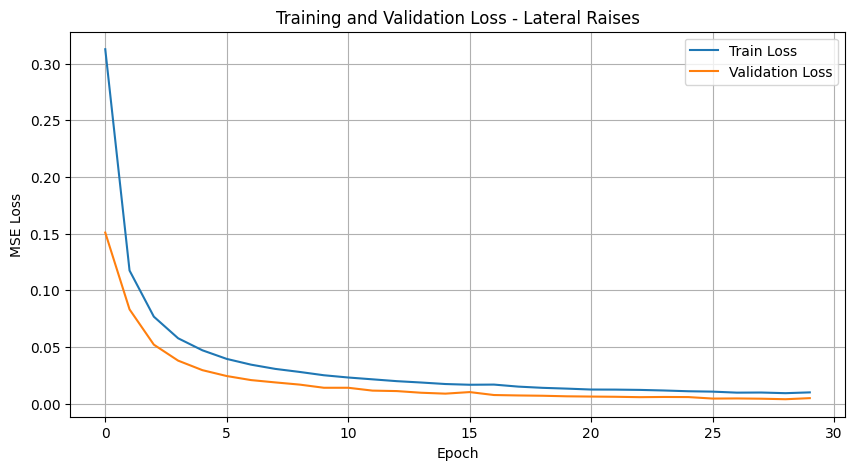

In [23]:
# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss - Lateral Raises')
plt.legend()
plt.grid(True)
plt.show()

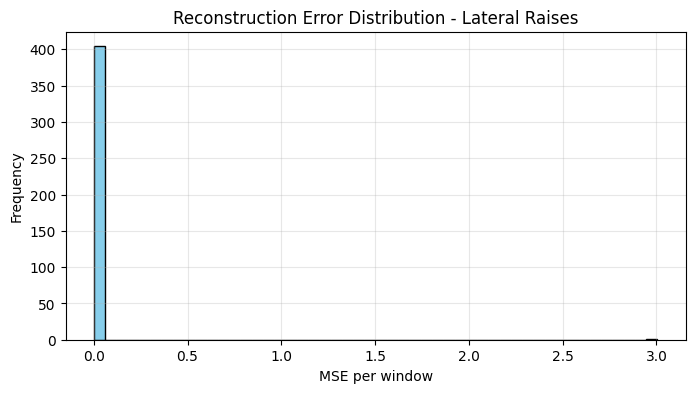

In [24]:
# Evaluate on test set
model.eval()
recon_errors = []
with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(device)
        recon_out = model(x_batch)
        batch_error = torch.mean((x_batch - recon_out) ** 2, dim=(1, 2)).cpu().numpy()
        recon_errors.extend(batch_error)

recon_errors = np.array(recon_errors)

plt.figure(figsize=(8, 4))
plt.hist(recon_errors, bins=50, color='skyblue', edgecolor='black')
plt.title("Reconstruction Error Distribution - Lateral Raises")
plt.xlabel("MSE per window")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
joblib.dump(scaler, "pose_scaler_push_up.pkl")
print("Scaler saved.")

Scaler saved.
